
**Curso: modelos de aprendizaje**

**UNIDAD 2**


---

*   NOMBRE:BRAYAN GRES JUAREZ
*   NO CONTROL:23111409



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
DIR = "/content/drive/MyDrive/ArchivosAnalitica/01 10 2026"
os.chdir(DIR)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para preprocesamiento e ing de características
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder,StandardScaler, OrdinalEncoder,FunctionTransformer

# Librerías para la canalización
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline

# Librerías para la regresión
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_squared_error, r2_score, confusion_matrix, precision_score,recall_score,accuracy_score
from sklearn.decomposition import PCA

from sklearn.preprocessing import PolynomialFeatures

data_df = pd.read_csv("data.csv")

---

## **<font color=" #895cf9">Explica brevemente el uso de las librerias del segmento de codigo anterior, haciendo uso de la siguiente tabla</font>**


| Library | Explanation  |
|----------|--------------|
|**pandas as pd**| Permite cargar, organizar y manipular datos mediante DataFrames.|
|**numpy as np**|Se utiliza para realizar operaciones numéricas y matemáticas.|
|**matplotlib.pyplot as plt**|Permite crear gráficas para visualizar los datos.|
|**seaborn as sns** |Facilita la creación de gráficas estadísticas.|
|**SimpleImputer** |Permite reemplazar valores faltantes en los datos.|
|**MinMaxScaler** |Escala los valores numéricos dentro de un rango, normalmente entre 0 y 1.|
|**OneHotEncoder** |Convierte variables categóricas en columnas numéricas binarias.|
|**StandardScaler** |Estandariza los datos para que tengan media 0 y desviación estándar 1.|
|**OrdinalEncoder**|Convierte categorías en valores numéricos siguiendo una codificación ordinal.|
|**FunctionTransformer** |Permite aplicar una función o transformación personalizada a los datos.|
|**ColumnTransformer** |Permite aplicar diferentes transformaciones a distintas columnas.|
|**make_column_selector** |Selecciona automáticamente columnas según su tipo de dato.|
|**make_pipeline** |Une varias etapas de procesamiento y modelado en un mismo flujo.|
|**LinearRegression** |Crea modelos de regresión lineal para predecir valores numéricos.|
**LogisticRegression** |Crea modelos de clasificación mediante regresión logística.|
**mean_squared_error** |Calcula el error cuadrático medio entre valores reales y predichos.|
**r2_score** |Mide qué tanto de la variación de los datos explica el modelo.|
**confusion_matrix** |Muestra los aciertos y errores de un modelo de clasificación.|
**precision_score** |Calcula qué proporción de predicciones positivas fue correcta.|
**recall_score** |Calcula qué proporción de casos positivos fue identificada correctamente.|
**accuracy_score** |Calcula la proporción total de predicciones correctas.|
**PCA** |Reduce la cantidad de variables conservando la información más importante.|
**PolynomialFeatures** |Genera nuevas características polinómicas para representar relaciones no lineales.|







---

In [4]:
#lectura del .csv con pandas


# **Parte 1**. EDA

Haz que el `id` sea el índice del dataframe y efectúa una exploración inicial de los datos a través de:

In [5]:
#utilice funcion .set_index()
#Guarde los cambios con inplace=True

#-----------------------------------------------------
#Escriba su codigo
data_df.set_index('id',inplace=True)
#-----------------------------------------------------

#-----------------------------------------------------


In [6]:
data_df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820




1a) Estadísticas descriptivas para todas las variables del dataframe.

In [7]:
#.describe para variables Numericas
#-----------------------------------------------------
numericas = data_df.select_dtypes(include = np.number)
numericas.describe()
#-----------------------------------------------------

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
#.describe() para variable categoricas
#-----------------------------------------------------
categoricas = data_df.select_dtypes(exclude = np.number)
categoricas.describe()
#-----------------------------------------------------

,diagnosis
count,569
unique,2
top,B
freq,357


1b) Valores únicos por variable para identificar posibles variables categóricas.

In [9]:
# Se hace una lista de variables numéricas y otra de categóricas.
#-----------------------------------------------------
num_cols = data_df.select_dtypes(include=np.number).columns.tolist() #para variables numericas
cat_cols = data_df.select_dtypes(exclude=np.number).columns.tolist() #para variables Categoricas
#-----------------------------------------------------

In [10]:
# Recuento de cada categoría única en las variables categóricas
data_df[cat_cols].nunique()

,0
diagnosis,2


In [11]:
# Recuento de cada categoría única en las variables categóricas
for col in cat_cols:
    print(col, data_df[col].unique())


diagnosis ['M' 'B']


1c) Búsqueda de valores faltantes.

In [12]:
# Muestra eltítulo
print('Número valores faltantes:')

# Recorre cada columna del DataFrame
for col in data_df.columns:

    # Cuenta cuántos valores faltantes hay en la columna
    valor = sum(data_df[col].isna())

    # Calcula el porcentaje de valores faltantes
    porcentaje = data_df[col].isna().mean() * 100

    # muestra nombre de la columna, cantidad y porcentaje
    print('{}: {} valores faltantes, porcentaje: {:.2f}%'.format(
        col, valor, porcentaje
    ))

Número valores faltantes:
diagnosis: 0 valores faltantes, porcentaje: 0.00%
radius_mean: 0 valores faltantes, porcentaje: 0.00%
texture_mean: 0 valores faltantes, porcentaje: 0.00%
perimeter_mean: 0 valores faltantes, porcentaje: 0.00%
area_mean: 0 valores faltantes, porcentaje: 0.00%
smoothness_mean: 0 valores faltantes, porcentaje: 0.00%
compactness_mean: 0 valores faltantes, porcentaje: 0.00%
concavity_mean: 0 valores faltantes, porcentaje: 0.00%
concave points_mean: 0 valores faltantes, porcentaje: 0.00%
symmetry_mean: 0 valores faltantes, porcentaje: 0.00%
fractal_dimension_mean: 0 valores faltantes, porcentaje: 0.00%
radius_se: 0 valores faltantes, porcentaje: 0.00%
texture_se: 0 valores faltantes, porcentaje: 0.00%
perimeter_se: 0 valores faltantes, porcentaje: 0.00%
area_se: 0 valores faltantes, porcentaje: 0.00%
smoothness_se: 0 valores faltantes, porcentaje: 0.00%
compactness_se: 0 valores faltantes, porcentaje: 0.00%
concavity_se: 0 valores faltantes, porcentaje: 0.00%
conca

1d) Diagrama de barras para determinar la frecuencia de los diagnósticos (cantidad de observaciones con resultado benigno y maligno)

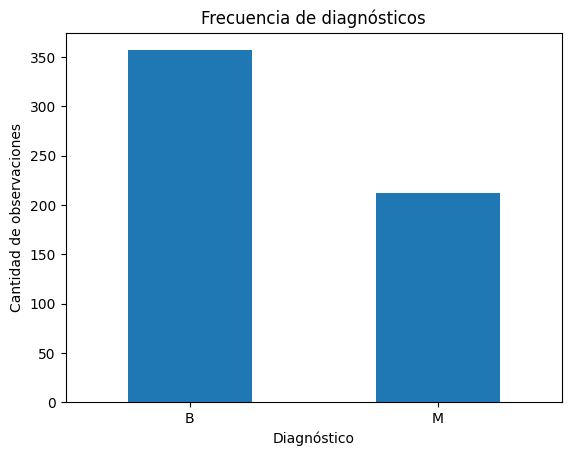

In [13]:
#utilice sns.countplot()
#-----------------------------------------------------
# Contar la frecuencia de cada diagnóstico
frecuencia = data_df['diagnosis'].value_counts()

frecuencia.plot(kind='bar')

plt.title('Frecuencia de diagnósticos')
plt.xlabel('Diagnóstico')
plt.ylabel('Cantidad de observaciones')
plt.xticks(rotation=0)

plt.show()
#-----------------------------------------------------

2. Como hay tres valores relacionados con la misma característica (`mean`, `se` y `worst`) es muy probable que exista multicolinealidad en el conjunto.

La multicolinealidad en regresión es una condición que ocurre cuando algunas variables predictoras están fuertemente correlacionadas entre sí, de tal manera que si se incluyen simultáneamente en un modelo, impiden explicar de manera correcta el efecto que cada una tiene sobre la variable respuesta. Existen muchas formas de analizar si hay colinealidad en los modelos, una de ellas es el alto coeficiente de correlación entre variables.

Para observar este efecto, elabora un mapa de calor que cuantifique la correlación de las variables numéricas en el dataframe.

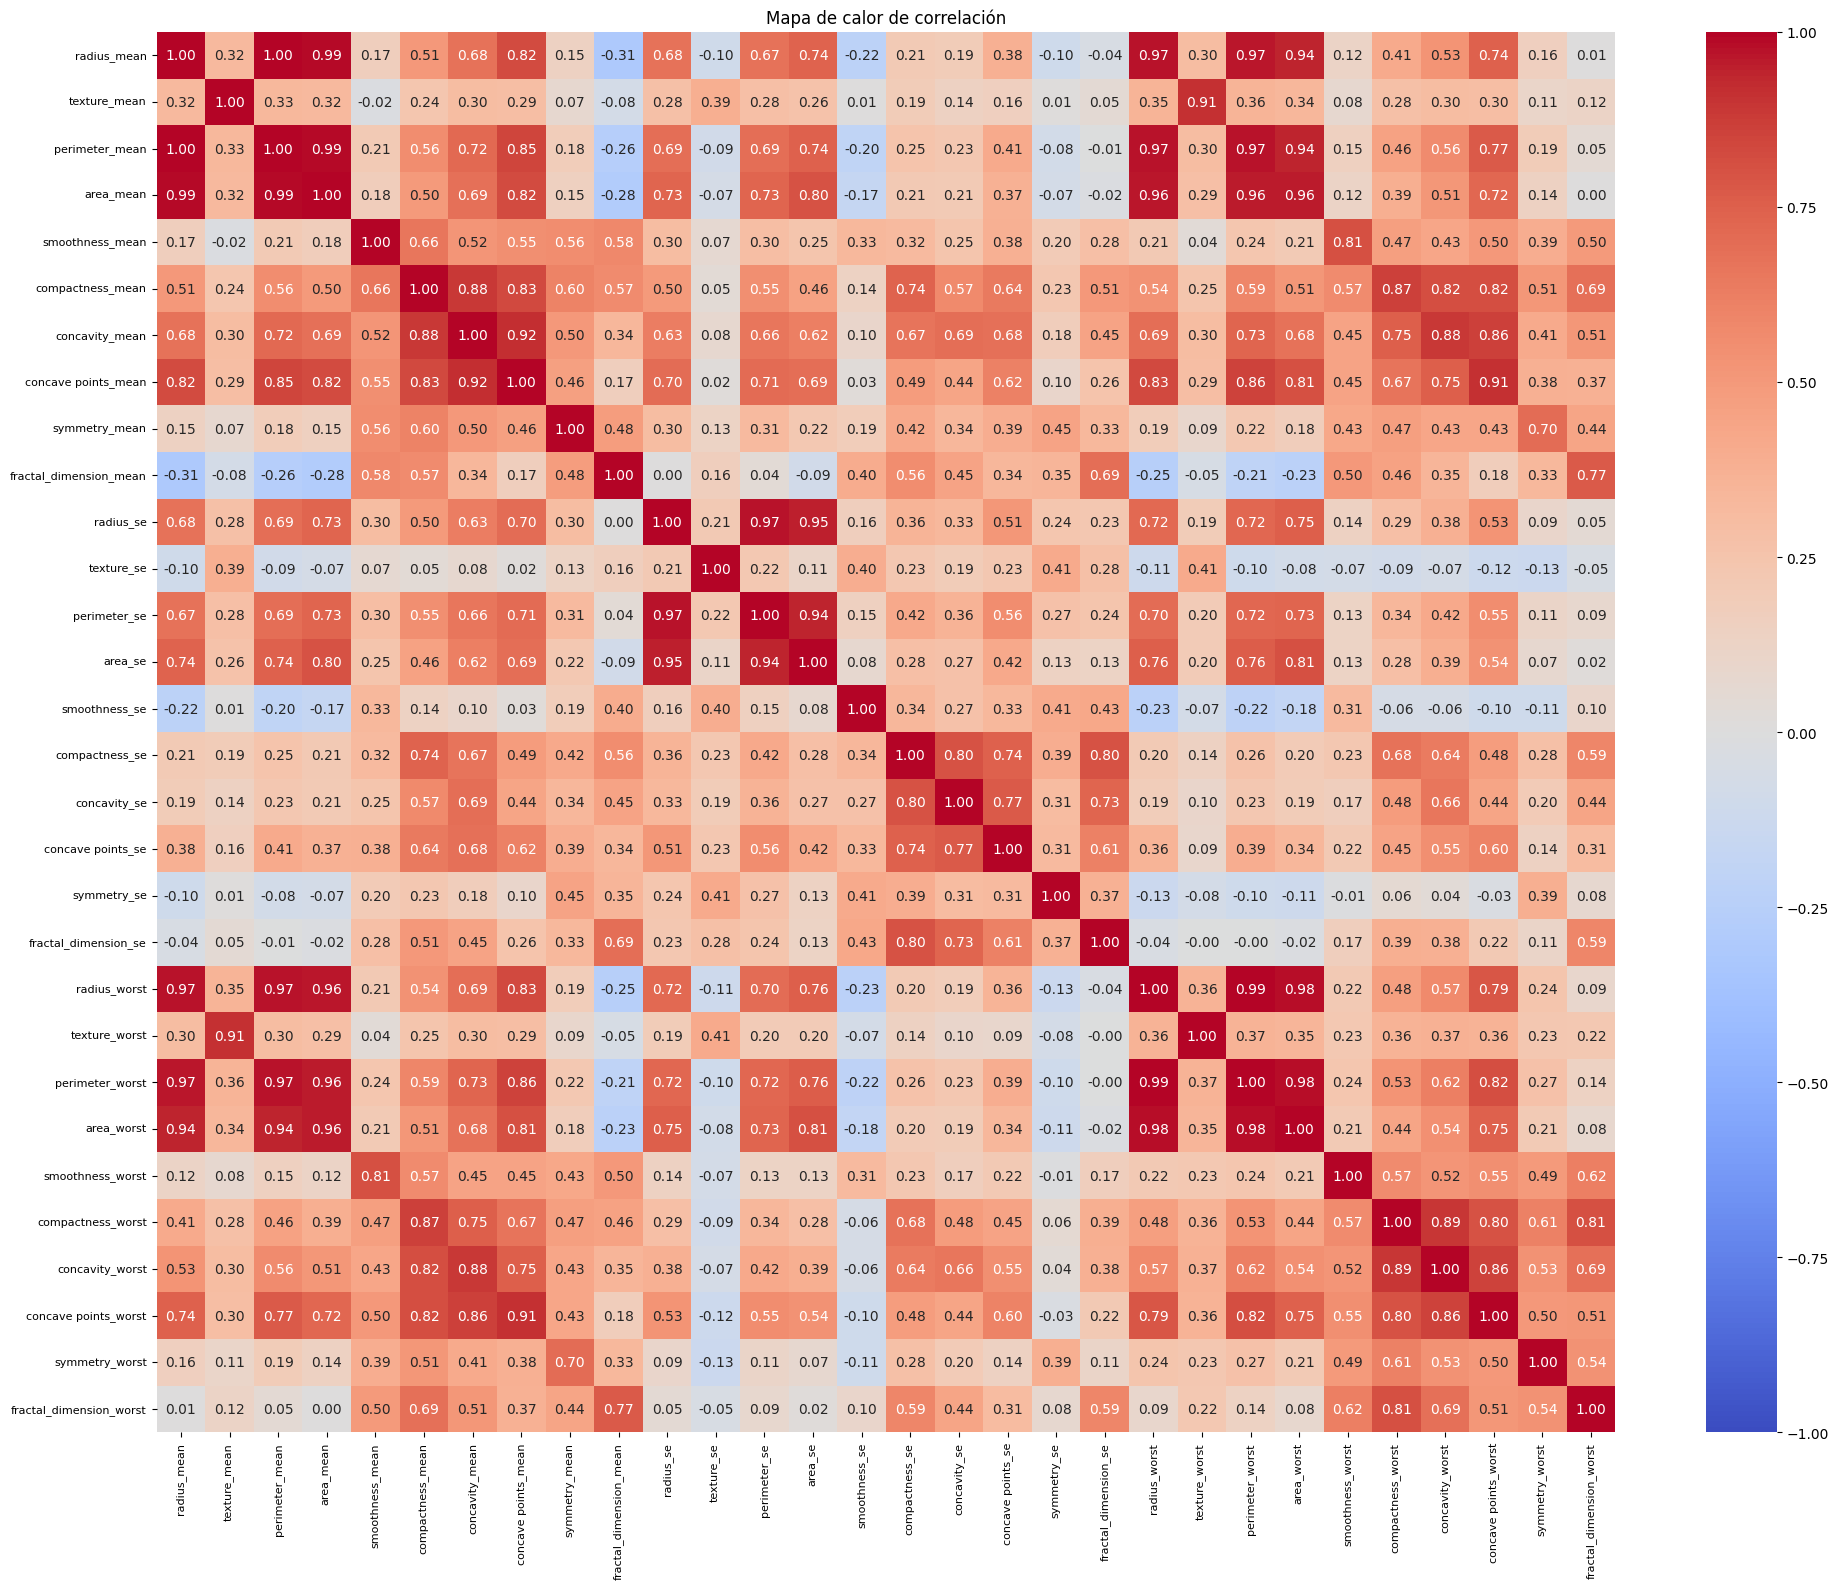

In [14]:
numeric_df = data_df.select_dtypes(include=[float, int])

#---------------------------------------------------
correlacion = numeric_df.corr()

plt.figure(figsize=(20, 16))

sns.heatmap(
    correlacion,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f'
)

plt.title('Mapa de calor de correlación')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

#------------------
#-----------------------------------------------------

Si te fijas en los valores de correlación entre las variables `_mean` y `_worst` es evidente la multicolinearidad.

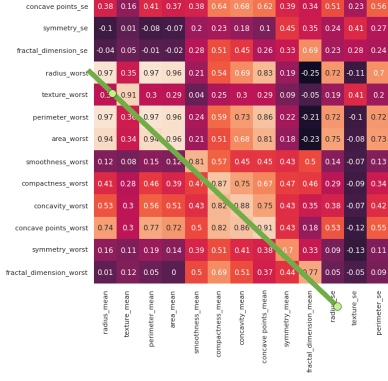

Por ejemplo, la columna `radius_mean` tiene una correlación de 0.97 con la columna `radius_worst`. Esto es algo inevitable, porque las columnas "peores" son esencialmente solo un subconjunto de las columnas "medias".

Para solucionar el problema numérico de la multicolinealidad, tradicionalmente se recurre a eliminar variables o efectuar análisis de componentes principales (PCA) con las `X`’s y usar los componentes como variables independientes en un modelo final.

Conduciremos esta actividad en esos dos sentidos.


# **Parte 2**. Modelo con eliminación de variables altamente correlacionadas  

Elimina las variables altamente correlacionadas:

3a) Ahora que sabes que las variables `_mean` y `_worst` tienen correlación alta, hay que quitar del dataframe un conjunto. Borra las columnas `_worst`.

In [15]:
#-----------------------------------------------------
#Elimine TODAS las columnas _worst
columnas_worst = [col for col in data_df.columns if col.endswith('_worst')]
#-----------------------------------------------------

#para borrar las columnas _worst
new_data_df = data_df.drop(columns=columnas_worst)

#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas

new_data_df = pd.DataFrame(new_data_df)
#-----------------------------------------------------
new_data_df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115


En las graficas de dispersion, los patrones lineales en los diagramas de dispersion se refieren a la relacion entre dos variables que sigue una tendencia aproximadamente en linea recta, ya sea en direccion ascendente o descentende

* **Patron lineal positivo**: Si la linea se inclina hacia arriba (de izquierda a derecha), indica que hay una relacion directa entre las variables: cuando la variable aumenta, la otra tambien lo hace, es decir, CORRELACION POSITIVA

* **Patron lineal negativo**: si la linea se incluna hacia abajo (de izquierda a derecha), indica quue cuando una variable aumenta, la otra disminuye, es decir, CORRELACION NEGATIVA

* **Patron lineal perfecto**, si los puntos siguen una linea recta perfecta, la relacion entre las variables es exactamente lineal, sin desviaciones.


3b. Entre las variables `_mean`, identifica patrones lineales con diagramas de dispersión usando:

    sns.pairplot(data=nuevo_df[['radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean']])



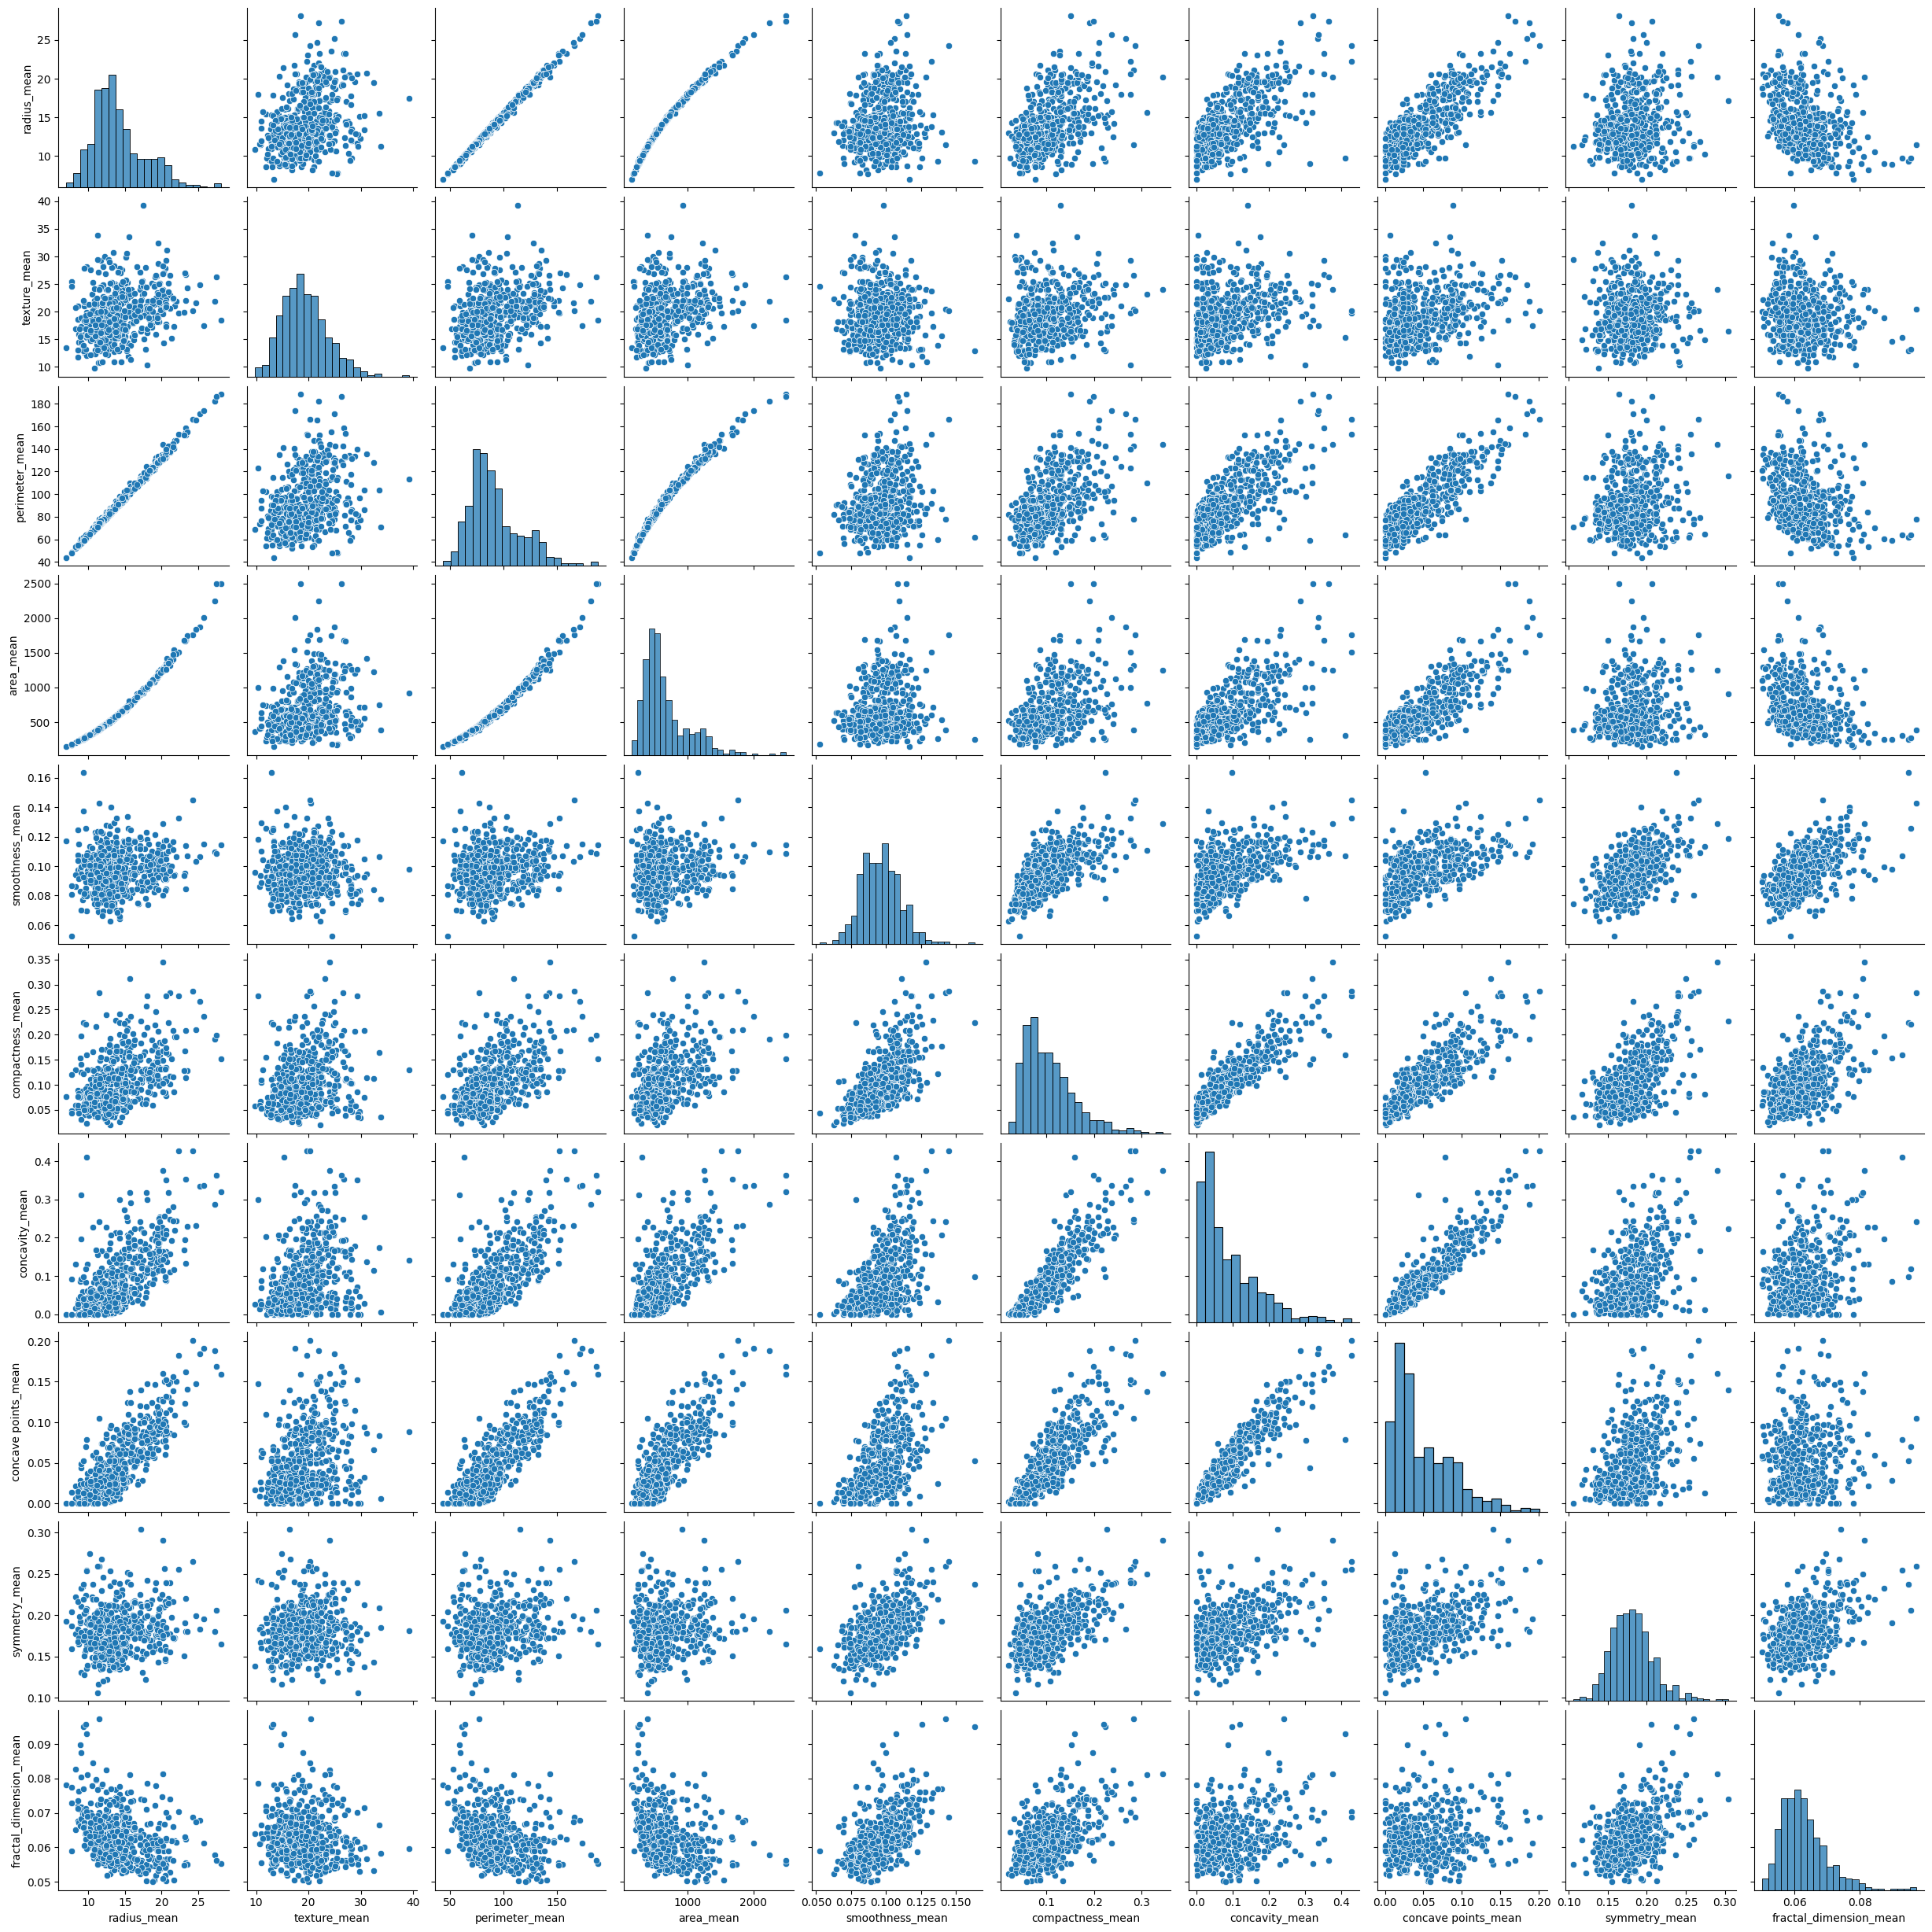

In [16]:
#-----------------------------------------------------
#Pega aqui el codigo sns.pairplot()
sns.pairplot(
    new_data_df[[
        'radius_mean',
        'texture_mean',
        'perimeter_mean',
        'area_mean',
        'smoothness_mean',
        'compactness_mean',
        'concavity_mean',
        'concave points_mean',
        'symmetry_mean',
        'fractal_dimension_mean'
    ]]
)

plt.show()
#-----------------------------------------------------

De la matriz podrás observar relaciones lineales bastante evidentes entre:


*   `radius_mean`, `perimeter_mean` y `area_mean`
*   `compactness_mean`, `concavity_mean`, `concave_points_mean`

Sabemos que el perímetro y el área de un círculo, se calculan a partir del radio. Entonces, la relación entre las primeras tres variables es muy clara para nosotros.

3c) Elabora otro mapa de calor confirmar con los valores de correlación.


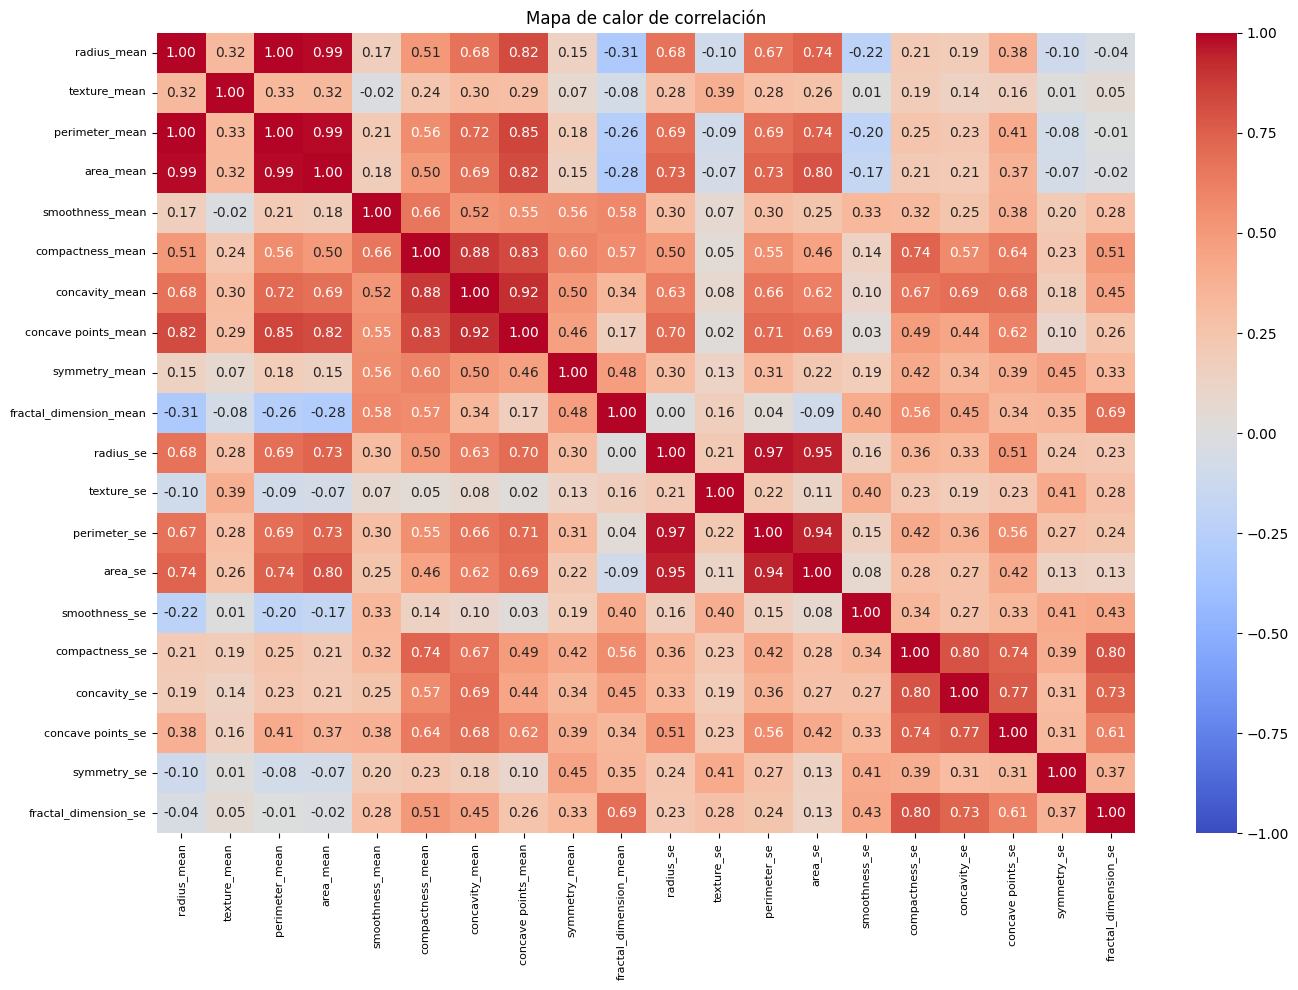

In [17]:
#-----------------------------------------------------
#Agrega codigo para el mapa de calor
#---------------------------------------------------
# Agrega codigo para el mapa de calor

numeric_new_df = new_data_df.select_dtypes(include=[float, int])

correlacion = numeric_new_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlacion,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt='.2f'
)

plt.title('Mapa de calor de correlación')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

#-----------------------------------------------------

3d) Después de observar los valores, nos quedaremos con sólo una variable de cada trío: `radius_mean` y `compactness_mean`. Elimina las restantes, no sólo del conjunto `_mean`, sino también de `_se`.

In [18]:

#-----------------------------------------------------
#escriba TODAS las columnas que seran eliminadas
columnas_a_eliminar = [
    'perimeter_mean',
    'area_mean',
    'concavity_mean',
    'concave points_mean',

    'perimeter_se',
    'area_se',
    'concavity_se',
    'concave points_se'
]
#-----------------------------------------------------



#-----------------------------------------------------
#Convierte new_data_df en Dataframe usando .DataFrame() de la libreria de pandas
new_data_df = pd.DataFrame(
    new_data_df.drop(columns=columnas_a_eliminar)
)
#-----------------------------------------------------
new_data_df

,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
id,,,,,,,,,,,,,
842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115
...,...,...,...,...,...,...,...,...,...,...,...,...,...
926424,M,21.56,22.39,0.11100,0.11590,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.01114,0.004239
926682,M,20.13,28.25,0.09780,0.10340,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.01898,0.002498
926954,M,16.60,28.08,0.08455,0.10230,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.01318,0.003892


Observa la distribución de las variables resultantes (deben ser 12, sin contar la columna de indice):

4a) Utilizando histogramas. Guarda en una variable (`skew_cols`) las que tengan marcado sesgo positivo. Para dar seguridad a tu selección, elige aquellas cuyo resultado de aplicar la función `skew()` sea mayor a 1.

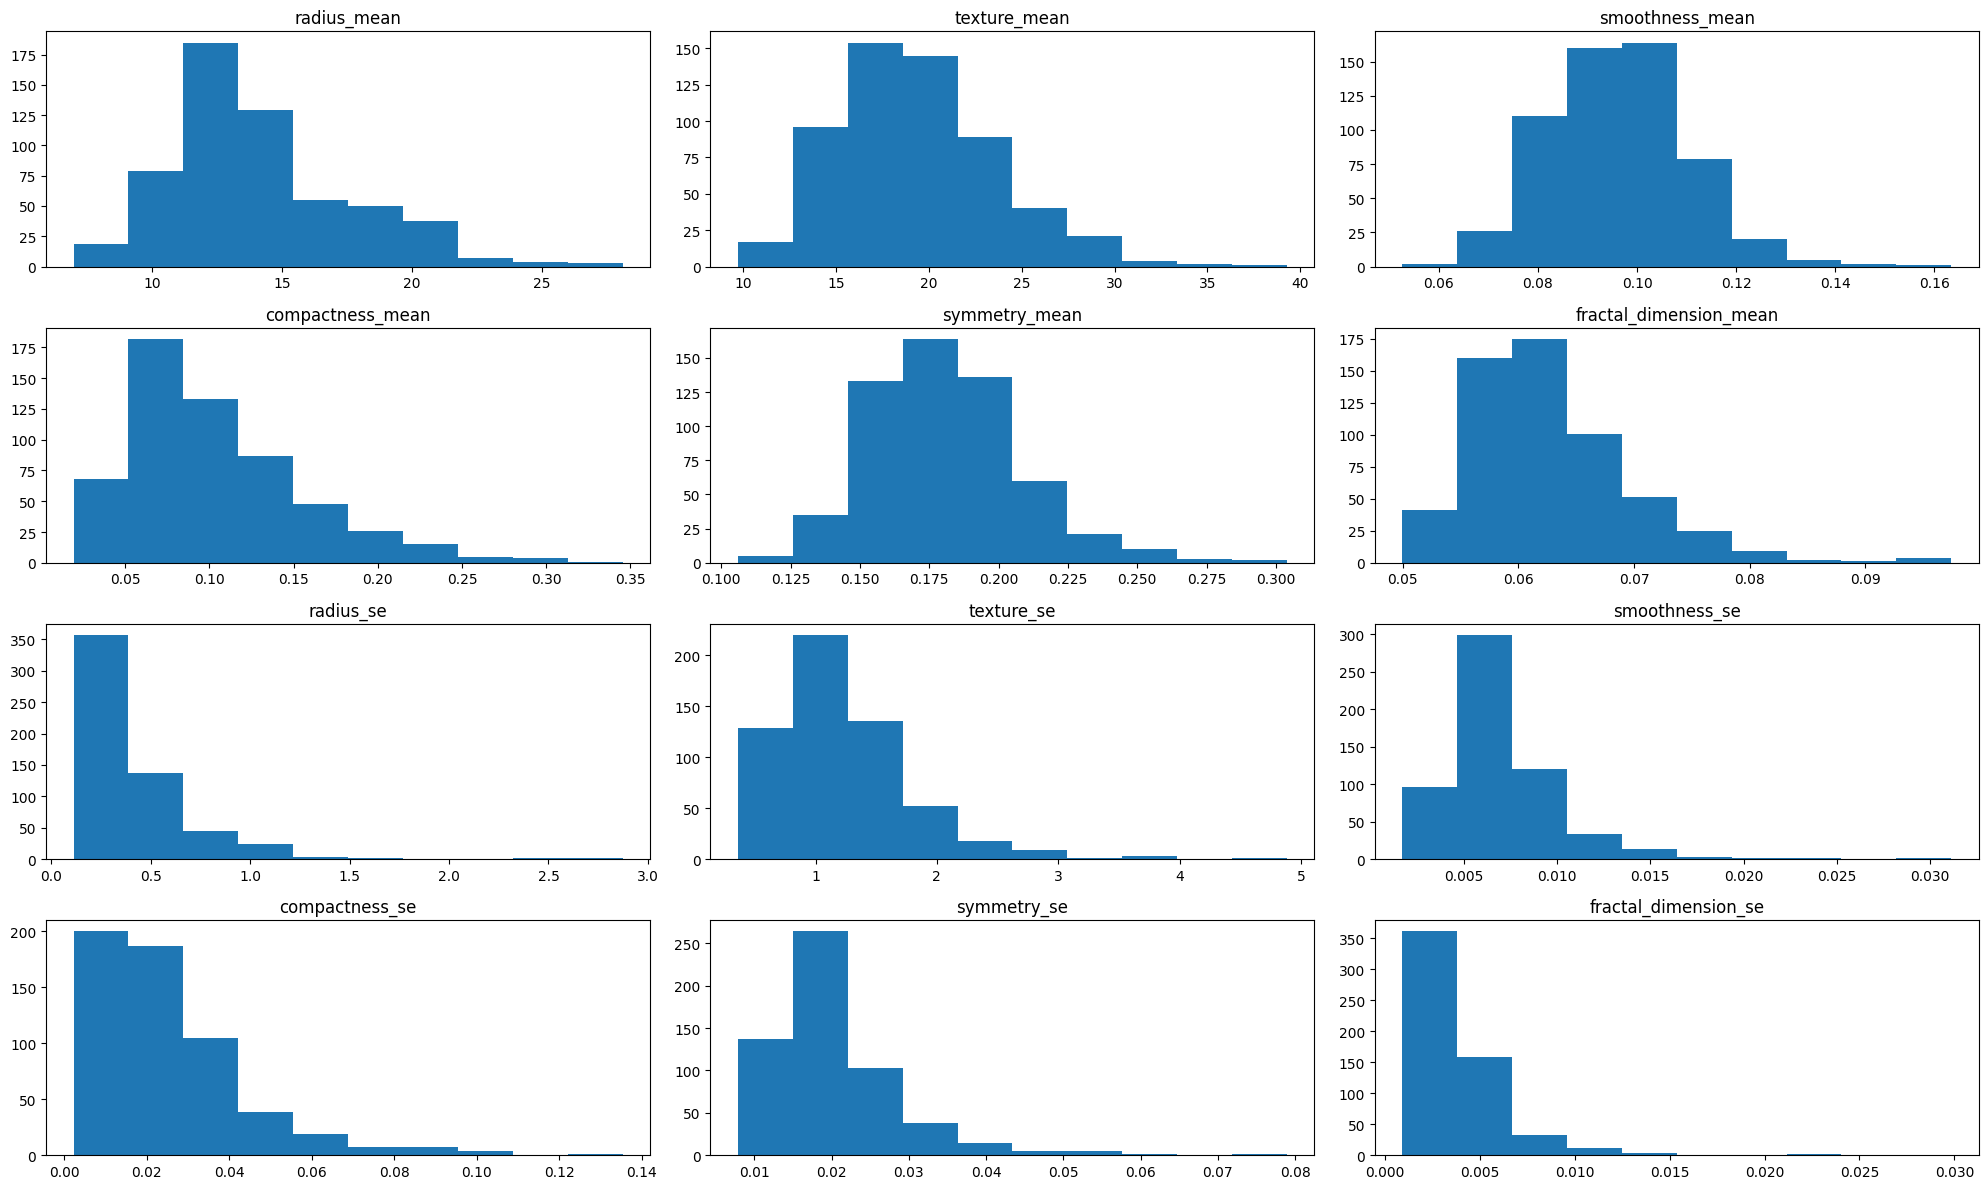

['compactness_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'smoothness_se',
 'compactness_se',
 'symmetry_se',
 'fractal_dimension_se']

In [19]:
#EXPLICA CADA LINEA DE CODIGO
# Obtener las columnas numéricas
num_cols = new_data_df.select_dtypes(include=np.number).columns.tolist()

# Lista donde se guardarán las variables con sesgo positivo fuerte
skew_cols = []

# Crear histogramas
fig, axes = plt.subplots(4, 3, figsize=(20, 12))
axes = axes.ravel()

for i, col in enumerate(num_cols):

    # Histograma
    if i < len(axes):
        axes[i].hist(new_data_df[col])
        axes[i].set_title(col)

    # Guardar variables con skew mayor a 1
    if new_data_df[col].skew() > 1:
        skew_cols.append(col)

plt.tight_layout()
plt.show()

# Mostrar las variables seleccionadas
skew_cols



In [20]:
skew_cols

['compactness_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'smoothness_se',
 'compactness_se',
 'symmetry_se',
 'fractal_dimension_se']

4b) Dibujando box plots de todas las variables. Guarda en una variable (`scale_cols`) aquellas que se encuentren en el intervalo [0,1]


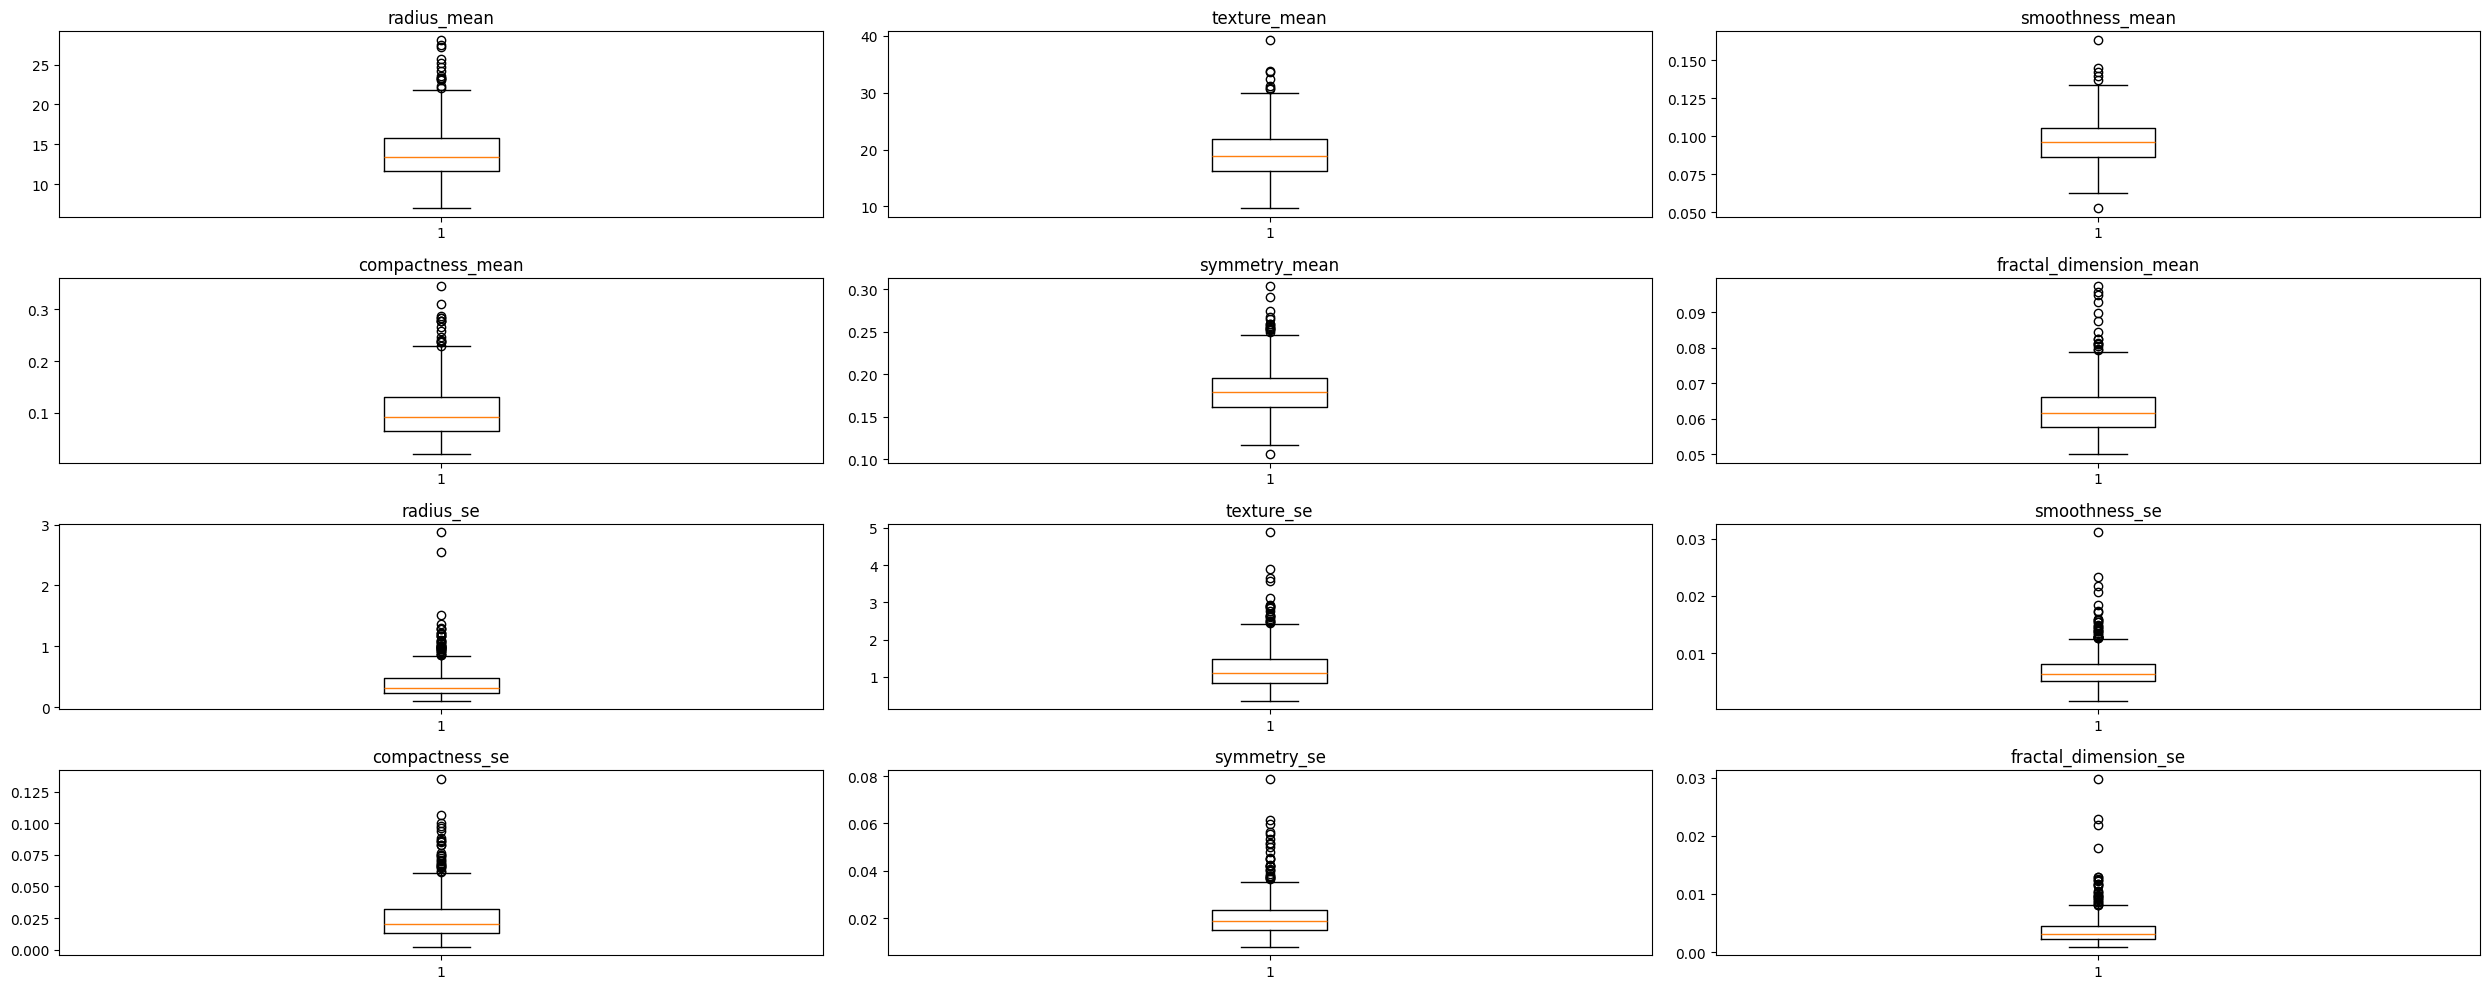

In [21]:
scale_cols_df=pd.DataFrame()
fig, axes = plt.subplots(4, 3, figsize=(25,10))
axes = axes.ravel()

for col, ax in zip(new_data_df[num_cols], axes):

    # Dibujar boxplot
    ax.boxplot(new_data_df[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()



Con todo el análisis anterior, estamos listos para generar un modelo *baseline* denominado `logr_model`. Para ello:

5a) Vuelve a leer el contenido del archivo, haz que el `id` sea el índice y separa las variables del dataframe: en `X` coloca los predictores y en `y` la variable de respuesta o salida (`diagnosis`). Divide el conjunto en entrenamiento y prueba (80:20) considerando el parámetro `random_state` con el valor de 1.

In [22]:
data_df = pd.read_csv('data.csv')

#-----------------------------------------------------
#AGREGA LINEA DE CODIGO PARA CONVERTIR COLUMNA "ID" EN INDICE
data_df.set_index('id', inplace=True)
#-----------------------------------------------------

In [23]:
X = data_df.copy() #Se crea copia del df


#-----------------------------------------------------
#                                  COMPLETA CODIGO
# se elimina variable Categorica "diagnosis" de (X), debido a se sera utilizada como variable de salida (y)
#-----------------------------------------------------
#Especifique la columna que desea eliminar
#Utilice el parametro axis=1, permitira eliminar la columna
#Guarde los cambios agregando el parametro inplace=True

X.drop('diagnosis', axis=1, inplace=True) #Caracteristica / variable Entrada
#-----------------------------------------------------

#-----------------------------------------------------
y = data_df['diagnosis'] #Objetivo /Variable salida
#-----------------------------------------------------

In [24]:
#Libreria necesaria para realizar la particion del conjunto de datos
# Librería necesaria para realizar la partición
from sklearn.model_selection import train_test_split

# 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=1
)

# Se divide el conjunto en entrenamiento y prueba (80:20), es decir, 80% para Entrenamiento (train) y 20% para Prueba (test)


5b) Prepara un transformador, denominado `preprocessing`, para borrar las columnas altamente correlacionadas (las 18 variables que se determinaron en los ejercicios previos) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.

In [25]:
#EXPLIQUE CADA LINEA DE CODIGO
# Se crea una lista con las 18 variables altamente correlacionadas
# que se eliminarán antes de entrenar el modelo.
columnas_a_eliminar=['radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst','compactness_worst','concavity_worst','concave points_worst','symmetry_worst','fractal_dimension_worst','perimeter_mean','area_mean','concavity_mean','concave points_mean','perimeter_se','area_se','concavity_se','concave points_se']
# Se crea el transformador llamado preprocessing.
preprocessing = ColumnTransformer([
    # 'num' es el nombre de esta transformación.
    # 'drop' indica que las columnas de la lista serán eliminadas.
    ('num', 'drop', columnas_a_eliminar)]
    # Las columnas que no fueron eliminadas se conservan sin cambios.
   ,remainder='passthrough')


5c) Entrena el modelo `logr_model` con el transformador `preprocessing` y  regresión logística.

Como la salida `y` está en términos de las etiquetas `'B'` y `'M'`, en lugar de 0 y 1, para evaluar el modelo en el conjunto de prueba deberás especificar la clase positiva. En el caso de la matriz de confusión, indica el orden de las etiquetas con `labels=['B','M']`, porque `'B'` es la clase negativa (ésta se especifica primero) y `'M'` la positiva. Para las métricas de *recall* y *precision*, utiliza el parámetro `pos_label='M'`. Como *accuracy* ocupa la suma de ambas clases y el total de las observaciones, no requiere ninguna especificación. Si quisieras omitir estos parámetros, tendrías que sustituir `'B'` por 0 y `'M'` por 1, previo a la construcción del modelo.

In [26]:
#EXPLIQUE CADA LINEA DE CODIGO

# Se crea un pipeline llamado logr_model que primero aplica el preprocesamiento
# y después utiliza un modelo de regresión logística.
logr_model = make_pipeline(preprocessing, LogisticRegression())

# Se entrena el modelo utilizando los datos de entrenamiento.
logr_model.fit(X_train, y_train)

# Se realizan predicciones con los datos de prueba.
predictions = logr_model.predict(X_test)

# Se muestra la matriz de confusión.
print('matriz de confusion :\n',
      confusion_matrix(y_test, predictions, labels=['B','M']))

# Calcula el recall tomando a M como la clase positiva.
print('recall :\t',
      recall_score(y_test, predictions, pos_label='M'))

# Calcula la precisión tomando a M como la clase positiva.
print('precision :\t',
      precision_score(y_test, predictions, pos_label='M'))

# Calcula la exactitud total del modelo.
print('accuracy :\t',
      accuracy_score(y_test, predictions))

matriz de confusion :
 [[68  4]
 [10 32]]
recall :	 0.7619047619047619
precision :	 0.8888888888888888
accuracy :	 0.8771929824561403


<font color=" ORANGE">INTERPRETE LOS RESULTADOS OBTENIDOS EN MATRIZ DE CONFUSION Y METRICAS

Para generar un modelo `logr_model2` con transformación y escalamiento:

6a) Modifica el transformador anterior para, además del borrado de las columnas correlacionadas, aplicar la raíz cuadrada a los predictores con sesgo (previamente almacenados en `skew_cols`) y escalamiento *MinMax* a los predictores con escala mayor a 1 (previamente almacenados en `scale_cols`) Como no todos los predictores serán eliminados o transformados, asegúrate de incluir el parámetro `remainder='passthrough'`

In [30]:
#EXPLIQUE CADA LINEA DE CODIGO
# Se definen las columnas que tienen escala mayor a 1 (no están en el rango [0,1])
scale_cols = ['radius_mean', 'texture_mean', 'radius_se', 'texture_se']

# Se crea un nuevo transformador llamado preprocessing2
preprocessing2 = ColumnTransformer([

    # Elimina las columnas altamente correlacionadas
    ('num0', 'drop', columnas_a_eliminar),

    # Aplica la raíz cuadrada a las variables con sesgo positivo
    ('num1', FunctionTransformer(np.sqrt), skew_cols),

    # Aplica escalamiento Min-Max a las variables que tienen escala mayor a 1
    ('num2', MinMaxScaler(), scale_cols)

# Las columnas que no fueron eliminadas ni transformadas
# se mantienen sin cambios
], remainder='passthrough')

6b) Entrena el modelo `logr_model2` con regresión logística, aplicando previamente el transformador modificado. Evalúa el modelo en el conjunto de prueba con las mismas métricas.

In [31]:
#ESCRIBA CODIGO AQUI
logr_model2 = make_pipeline(preprocessing2, LogisticRegression())
logr_model2.fit(X_train, y_train)
predictions2 = logr_model2.predict(X_test)
print('matriz de confusion:\n', confusion_matrix(y_test, predictions2, labels=['B', 'M']))
print('recall:\t', recall_score(y_test, predictions2, pos_label='M'))
print('precision:\t', precision_score(y_test, predictions2, pos_label='M'))
print('accuracy:\t', accuracy_score(y_test, predictions2))

matriz de confusion:
 [[72  0]
 [11 31]]
recall:	 0.7380952380952381
precision:	 1.0
accuracy:	 0.9035087719298246


<font color=" ORANGE">INTERPRETE LOS RESULTADOS OBTENIDOS EN MATRIZ DE CONFUSION Y METRICAS

Al comparar la matriz de confusión y las métricas obtenidas, se puede observar que el modelo logra clasificar correctamente la mayoría de los casos. El recall permite ver qué tan bien identifica los casos malignos, mientras que la precisión indica qué tan confiables son esas predicciones. La accuracy muestra el porcentaje general de aciertos del modelo. Después de aplicar el preprocesamiento, es posible comparar si el segundo modelo mejora o mantiene un rendimiento similar al modelo inicial.

<font color=" ORANGE">CONCLUSION DE LA PRACTICA

En esta práctica se realizó todo el proceso necesario para construir un modelo de regresión logística, desde la exploración y preparación de los datos hasta la evaluación final. Primero se identificaron variables altamente correlacionadas, variables con sesgo y variables que necesitaban escalamiento. Después se aplicaron distintas transformaciones y se entrenaron dos modelos para comparar sus resultados. Esto permitió entender que el preprocesamiento de los datos puede influir directamente en el desempeño del modelo y que no basta con entrenarlo, sino que también es importante analizar correctamente las variables antes de utilizarlo.